# Hugging Face

## Text Classification

In [1]:
from transformers import pipeline
import matplotlib.pyplot as plt


Load a pretrained pipeline

In [2]:
classifier = pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device set to use cuda:0


Test

In [4]:
print(classifier("I hate using Hugging Face!"))

[{'label': 'NEGATIVE', 'score': 0.9792759418487549}]


In [5]:
print(classifier("I hate long codes."))

[{'label': 'NEGATIVE', 'score': 0.9962122440338135}]


## Image Classification



Load image classification pipeline

In [6]:
classifier = pipeline("image-classification", model="google/vit-base-patch16-224")


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
Device set to use cuda:0


Run on an image

In [7]:
results = classifier("/content/drive/MyDrive/CVIS/cat.jpg")

print(results)


[{'label': 'tabby, tabby cat', 'score': 0.4632818400859833}, {'label': 'Egyptian cat', 'score': 0.4611452519893646}, {'label': 'tiger cat', 'score': 0.06906603276729584}, {'label': 'lynx, catamount', 'score': 0.002132825320586562}, {'label': 'Siamese cat, Siamese', 'score': 0.0001998342777369544}]


In [8]:
for i in results:
  print(i)

{'label': 'tabby, tabby cat', 'score': 0.4632818400859833}
{'label': 'Egyptian cat', 'score': 0.4611452519893646}
{'label': 'tiger cat', 'score': 0.06906603276729584}
{'label': 'lynx, catamount', 'score': 0.002132825320586562}
{'label': 'Siamese cat, Siamese', 'score': 0.0001998342777369544}


In [9]:
results = classifier("/content/drive/MyDrive/CVIS/dog.jpg")

for i in results:
  print(i)

{'label': 'golden retriever', 'score': 0.9052882194519043}
{'label': 'Labrador retriever', 'score': 0.061327025294303894}
{'label': 'Sussex spaniel', 'score': 0.005652552470564842}
{'label': 'miniature poodle', 'score': 0.003055797889828682}
{'label': 'cocker spaniel, English cocker spaniel, cocker', 'score': 0.003002642188221216}


# FineTuning a BERT Transformer using Hugging face

In [ ]:
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import load_dataset

train_ds = load_dataset("imdb", split="train[:25%]")
test_ds  = load_dataset("imdb", split="test[:10%]")


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Tokenizer

In [ ]:


tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [ ]:

def tokenize(batch):
    return tokenizer(batch['text'], padding=True, truncation=True)

tokenized_train = train_ds.map(tokenize, batched=True)
tokenized_test  = test_ds.map(tokenize, batched=True)


Map:   0%|          | 0/6250 [00:00<?, ? examples/s]

Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

Load model

In [ ]:
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training settings

In [ ]:
training_args = TrainingArguments(
    output_dir="./results",
    report_to="none",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
)

Trainer

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
)

Fine-tune BERT

In [ ]:
trainer.train()

Step,Training Loss
500,0.004900
1000,0.000000


TrainOutput(global_step=1173, training_loss=0.002120589775105546, metrics={'train_runtime': 1729.5575, 'train_samples_per_second': 10.841, 'train_steps_per_second': 0.678, 'total_flos': 4933332288000000.0, 'train_loss': 0.002120589775105546, 'epoch': 3.0})

# Using Multimodal Models

In [10]:
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import requests
import torch

Load the model

In [11]:
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Load the image

In [12]:
image = Image.open('/content/drive/MyDrive/CVIS/dog.jpg')

Texts that we are going to find similarities based on model

In [13]:
texts = ["A screenshot of a code",
         "a photo of a dog",
         "an illustration of a cat",
         "two dog in grass"]

In [14]:
inputs = processor(text=texmages=image, return_tensors="pt", padding=True)
ts, i

In [ ]:
outputs = model(**inputs)
logits_per_image = outputs.logits_per_image  # similarity scores (image → text)
probs = logits_per_image.softmax(dim=1)      # normalized probabilities

print("Texts:", texts)
print("Probabilities:", probs)

Texts: ['A screenshot of a code', 'a photo of a dog', 'an illustration of a cat', 'two dog in grass']
Probabilities: tensor([[9.0603e-06, 3.5041e-03, 3.5715e-07, 9.9649e-01]],
       grad_fn=<SoftmaxBackward0>)


# Generate Caption for an Image

In [15]:
from transformers import VisionEncoderDecoderModel, ViTImageProcessor, AutoTokenizer
from PIL import Image
import requests
import torch

In [16]:
model = VisionEncoderDecoderModel.from_pretrained("nlpconnect/vit-gpt2-image-captioning")
feature_extractor = ViTImageProcessor.from_pretrained("nlpconnect/vit-gpt2-image-captioning")
tokenizer = AutoTokenizer.from_pretrained("nlpconnect/vit-gpt2-image-captioning")


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/982M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/982M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/228 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/241 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/120 [00:00<?, ?B/s]

In [17]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

VisionEncoderDecoderModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (inte

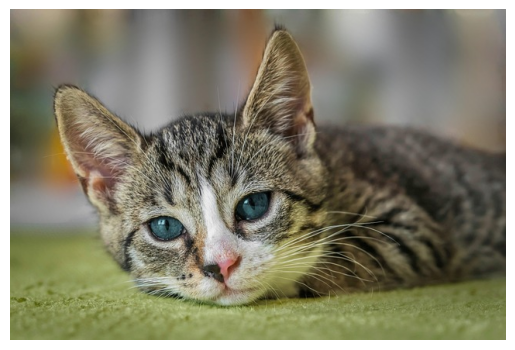

In [22]:
image = Image.open('/content/drive/MyDrive/CVIS/cat.jpg')
plt.imshow(image)
plt.axis("off")
plt.show()

In [23]:
pixel_values = feature_extractor(images=image, return_tensors="pt").pixel_values.to(device)


In [24]:
output_ids = model.generate(pixel_values, max_length=16, num_beams=4)
caption = tokenizer.decode(output_ids[0], skip_special_tokens=True)

In [25]:
print("Generated Caption:", caption)

Generated Caption: a gray and white cat laying on a rug 


# Using LLMs using GROQ

In [26]:
!pip install groq


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.4/131.4 kB 6.2 MB/s eta 0:00:00


In [28]:
import os
from groq import Groq

In [29]:
groq_api_key = "Copy it from GROQ Website"

In [30]:
client = Groq(api_key=groq_api_key)


In [37]:
messages = [
    {"role": "system", "content": "You are a concise assistant. You will only generate the code of the function user asked for. Do not give anything else"},
    {"role": "user", "content": "Write a code to calculate the area of a circle"}
]

In [38]:
response = client.chat.completions.create(
    model="llama-3.1-8b-instant",
    messages=messages,
    temperature=0.2,
    max_tokens=150
)

print(response.choices[0].message.content)


```python
import math

def calculate_circle_area(radius):
    return math.pi * (radius ** 2)
```


## Using GROQ for multimodal Tasks

In [39]:
import base64

In [41]:
image_path = '/content/drive/MyDrive/CVIS/dog.jpg'



Convert local image to base64



In [42]:
with open(image_path, "rb") as f:
    image_base64 = base64.b64encode(f.read()).decode("utf-8")

In [43]:
import base64

with open(image_path, "rb") as f:
    image_bytes = f.read()

print("First 200 bytes of raw binary:\n")
print(image_bytes[:300])
# Convert to base64
image_base64 = base64.b64encode(image_bytes).decode("utf-8")

print("First 300 characters of Base64:\n")
print(image_base64[:300])


First 200 bytes of raw binary:

b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x01\x00H\x00H\x00\x00\xff\xe2\x0cXICC_PROFILE\x00\x01\x01\x00\x00\x0cHLino\x02\x10\x00\x00mntrRGB XYZ \x07\xce\x00\x02\x00\t\x00\x06\x001\x00\x00acspMSFT\x00\x00\x00\x00IEC sRGB\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\xf6\xd6\x00\x01\x00\x00\x00\x00\xd3-HP  \x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x11cprt\x00\x00\x01P\x00\x00\x003desc\x00\x00\x01\x84\x00\x00\x00lwtpt\x00\x00\x01\xf0\x00\x00\x00\x14bkpt\x00\x00\x02\x04\x00\x00\x00\x14rXYZ\x00\x00\x02\x18\x00\x00\x00\x14gXYZ\x00\x00\x02,\x00\x00\x00\x14bXYZ\x00\x00\x02@\x00\x00\x00\x14dmnd\x00\x00\x02T\x00\x00\x00pdmdd\x00\x00\x02\xc4\x00\x00\x00\x88vued\x00\x00\x03L\x00\x00\x00\x86view\x00\x00\x03\xd4\x00\x00'
First 300 characters of Base64:

/9j/4AAQSkZJRgABAgEASABIAAD/4gxYSUNDX1BST0ZJTEUAAQEAAAxITGlu

In [44]:
messages = [
        {
            "role": "user",
            "content": [
                {"type": "text", "text": "Describe this image in one sentence."},
                {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{image_base64}"}}
            ]
        }
    ]

response = client.chat.completions.create(
    model="meta-llama/llama-4-scout-17b-16e-instruct",  # multimodal-capable model
    messages=messages,
    max_completion_tokens=200,
)

In [45]:
print("Model Response:", response.choices[0].message.content)


Model Response: The image depicts two adorable Golden Retriever puppies sitting side by side in a lush green field scattered with vibrant orange leaves.


# A simple Chatbot

In [47]:
print("🤖 Groq Chatbot! (type 'quit' to stop)\n")

# Store conversation history
messages = [
    {"role": "system", "content": "You are a helpful and concise chatbot. Your answer should be limited to 2 sentences"}
]

while True:
    user_input = input("You: ")

    if user_input.lower() in ["quit", "exit", "bye"]:
        print("Bot: Goodbye! 👋")
        break

    # Add user message to history
    messages.append({"role": "user", "content": user_input})

    # Call Groq API with full history
    response = client.chat.completions.create(
        model="llama3-8b-8192",
        messages=messages,
        temperature=0.7,
        max_tokens=200
    )

    bot_reply = response.choices[0].message.content
    print("Bot:", bot_reply)

    # Save bot reply in history
    messages.append({"role": "assistant", "content": bot_reply})

🤖 Groq Chatbot! (type 'quit' to stop)

You: Hello
Bot: Hello! It's nice to chat with you, is there something I can help you with or would you like to chat about a specific topic?
You: How LLM works?
Bot: Large Language Models (LLMs) like myself are trained on vast amounts of text data to learn patterns and relationships between words, enabling me to generate human-like responses to user input. This is achieved through a process called deep learning, where complex algorithms analyze the data to identify connections and make predictions.
You: quit
Bot: Goodbye! 👋


# Using Streamlit

In [ ]:
# Try it yourself